In [26]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [34]:
PROCESSED_DATA = Path("../data/processed/")
FIGURES_PATH = Path("../reports/figures/")
INTERIM_DATA = Path("../data/interim/")

In [28]:
users = pd.read_parquet(PROCESSED_DATA/ "users.parquet")
transactions = pd.read_parquet(PROCESSED_DATA/ "transactions.parquet")
merchants = pd.read_parquet(PROCESSED_DATA/ "merchants.parquet")

In [29]:
users.head()

,user_id,age,sex,education,primary_source_of_income,sum_of_monthly_installments,sum_of_monthly_expenses,country,signup_date,risk_score
0,U00001,56,Other,High School,Employment,477.69,243.18,Finland,2021-04-01,0.571079
1,U00002,36,Female,Bachelor,Business,31.60,737.76,France,2020-07-07,0.705268
2,U00003,70,Other,High School,Student Aid,275.72,1477.50,Finland,2022-08-23,0.429579
3,U00004,38,Other,High School,Savings,288.29,1135.03,Belgium,2022-05-21,0.581384
4,U00005,61,Male,High School,Employment,7.00,892.76,Italy,2022-03-15,0.420227


In [30]:
transactions.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,is_international,session_length_seconds,is_first_time_merchant,is_fraud
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,1,145,0,0
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,1,32,1,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,1,604,1,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,0,1031,1,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,1,330,0,0


In [31]:
merchants.head()

,merchant_id,category,country,trust_score,number_of_alerts_last_6_months,avg_transaction_amount,account_age_months,has_fraud_history
0,M0001,travel,Austria,1.000000,3,97.23,84,0
1,M0002,clothing,Poland,0.689695,2,142.71,93,1
2,M0003,electronics,Czech Republic,0.834610,5,67.83,65,0
3,M0004,electronics,Belgium,0.607229,1,16.77,9,1
4,M0005,grocery,Ireland,0.641901,2,38.56,100,0


In [32]:
df = transactions.merge(users, on="user_id", how="left"). merge(merchants, on="merchant_id", how="left", suffixes=("_user","_merchant"))

In [33]:
df

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,...,country_user,signup_date,risk_score,category,country_merchant,trust_score,number_of_alerts_last_6_months,avg_transaction_amount,account_age_months,has_fraud_history
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,...,Sweden,2022-08-10,0.426675,travel,France,0.581711,3,74.97,23,1
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,...,France,2024-05-22,0.729627,electronics,Germany,0.568933,2,56.92,23,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,...,Italy,2021-05-18,0.393848,gaming,Denmark,0.608070,5,98.93,75,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,...,Portugal,2021-09-05,0.393405,electronics,Portugal,0.592656,4,21.60,82,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,...,Austria,2023-06-01,0.524168,gaming,Spain,0.450223,4,60.61,82,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,TX499995,2022-04-19 18:12:00,U00062,M0079,11.53,in-store,EUR,iOS,"{'lat': 65.503521, 'long': 13.05648}",bank_transfer,...,Poland,2021-09-08,0.514065,travel,Sweden,0.295231,0,1.26,12,1
499996,TX499996,2023-06-02 06:59:00,U17320,M0760,78.01,mobile,EUR,iOS,"{'lat': 48.568223, 'long': -7.713759}",bank_transfer,...,Poland,2022-10-28,0.508625,restaurants,Italy,0.700921,1,40.48,33,0
499997,TX499997,2022-08-06 13:14:00,U07750,M0215,77.65,in-store,EUR,iOS,"{'lat': 46.172673, 'long': 35.355061}",bank_transfer,...,Czech Republic,2023-10-26,0.592257,education,Spain,0.797026,4,15.81,111,1
499998,TX499998,2023-03-20 22:00:00,U14492,M0848,221.38,online,EUR,iOS,"{'lat': 65.904775, 'long': 28.680062}",mobile_payment,...,Ireland,2024-12-02,0.419711,electronics,Netherlands,1.000000,7,38.62,7,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   transaction_id                  500000 non-null  object        
 1   timestamp                       500000 non-null  datetime64[ns]
 2   user_id                         500000 non-null  object        
 3   merchant_id                     500000 non-null  object        
 4   amount                          500000 non-null  float64       
 5   channel                         500000 non-null  object        
 6   currency                        500000 non-null  object        
 7   device                          500000 non-null  object        
 8   location                        500000 non-null  object        
 9   payment_method                  500000 non-null  object        
 10  is_international                500000 non-null  int64  

In [20]:
df.head()

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,...,country_user,signup_date,risk_score,category,country_merchant,trust_score,number_of_alerts_last_6_months,avg_transaction_amount,account_age_months,has_fraud_history
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,...,Sweden,2022-08-10,0.426675,travel,France,0.581711,3,74.97,23,1
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,...,France,2024-05-22,0.729627,electronics,Germany,0.568933,2,56.92,23,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,...,Italy,2021-05-18,0.393848,gaming,Denmark,0.608070,5,98.93,75,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,...,Portugal,2021-09-05,0.393405,electronics,Portugal,0.592656,4,21.60,82,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,...,Austria,2023-06-01,0.524168,gaming,Spain,0.450223,4,60.61,82,0


In [36]:
df.to_parquet(INTERIM_DATA/"merge_data.parquet")

In [37]:
data = pd.read_parquet(INTERIM_DATA/ "merge_data.parquet")

In [38]:
data

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,...,country_user,signup_date,risk_score,category,country_merchant,trust_score,number_of_alerts_last_6_months,avg_transaction_amount,account_age_months,has_fraud_history
0,TX000000,2022-06-17 23:28:00,U14804,M0314,130.03,in-store,EUR,Android,"{'lat': 40.057938, 'long': 14.959737}",debit_card,...,Sweden,2022-08-10,0.426675,travel,France,0.581711,3,74.97,23,1
1,TX000001,2022-01-04 15:39:00,U16634,M0675,132.00,online,EUR,Android,"{'lat': 42.05935, 'long': 1.596625}",debit_card,...,France,2024-05-22,0.729627,electronics,Germany,0.568933,2,56.92,23,0
2,TX000002,2022-09-09 21:58:00,U18005,M0479,8.65,online,EUR,Android,"{'lat': 50.923432, 'long': 21.795262}",credit_card,...,Italy,2021-05-18,0.393848,gaming,Denmark,0.608070,5,98.93,75,0
3,TX000003,2023-11-20 06:40:00,U13690,M0538,19.82,mobile,EUR,iOS,"{'lat': 56.833396, 'long': -9.881566}",credit_card,...,Portugal,2021-09-05,0.393405,electronics,Portugal,0.592656,4,21.60,82,0
4,TX000004,2022-04-28 08:08:00,U04642,M0128,101.92,in-store,EUR,Android,"{'lat': 54.042996, 'long': 2.168516}",credit_card,...,Austria,2023-06-01,0.524168,gaming,Spain,0.450223,4,60.61,82,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,TX499995,2022-04-19 18:12:00,U00062,M0079,11.53,in-store,EUR,iOS,"{'lat': 65.503521, 'long': 13.05648}",bank_transfer,...,Poland,2021-09-08,0.514065,travel,Sweden,0.295231,0,1.26,12,1
499996,TX499996,2023-06-02 06:59:00,U17320,M0760,78.01,mobile,EUR,iOS,"{'lat': 48.568223, 'long': -7.713759}",bank_transfer,...,Poland,2022-10-28,0.508625,restaurants,Italy,0.700921,1,40.48,33,0
499997,TX499997,2022-08-06 13:14:00,U07750,M0215,77.65,in-store,EUR,iOS,"{'lat': 46.172673, 'long': 35.355061}",bank_transfer,...,Czech Republic,2023-10-26,0.592257,education,Spain,0.797026,4,15.81,111,1
499998,TX499998,2023-03-20 22:00:00,U14492,M0848,221.38,online,EUR,iOS,"{'lat': 65.904775, 'long': 28.680062}",mobile_payment,...,Ireland,2024-12-02,0.419711,electronics,Netherlands,1.000000,7,38.62,7,1


In [40]:
df["currency"].value_counts()

currency
EUR    500000
Name: count, dtype: int64

### Users vs is_fraud

In [47]:
frauds_per_user =df.groupby('user_id')['is_fraud'].sum()

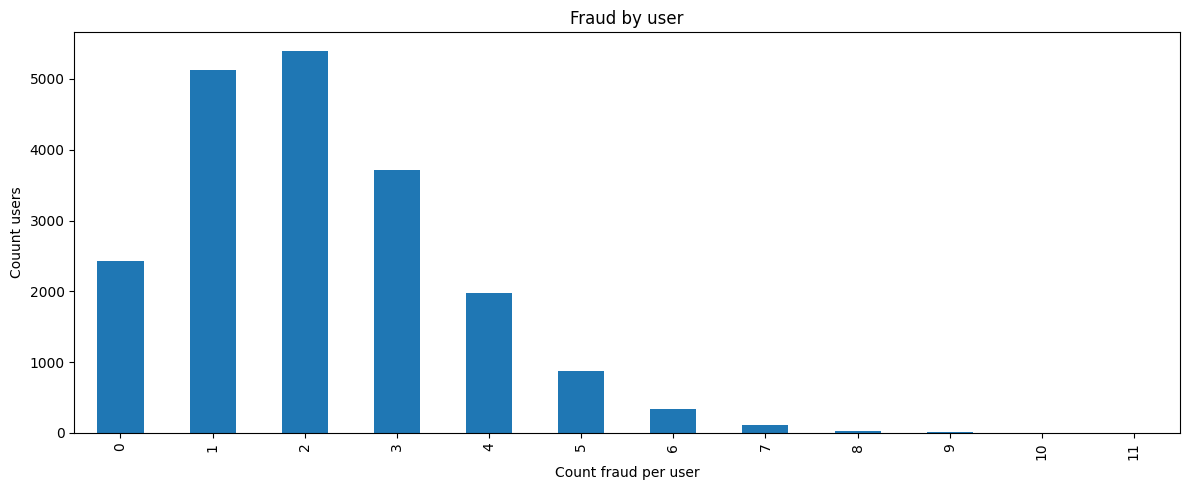

In [49]:
fig, ax = plt.subplots(figsize=(12,5))

frauds_per_user.value_counts().sort_index().plot(ax=ax, kind="bar")

ax.set_xlabel("Count fraud per user")
ax.set_ylabel("Couunt users")
ax.set_title("Fraud by user")


fig.tight_layout()
plt.show()

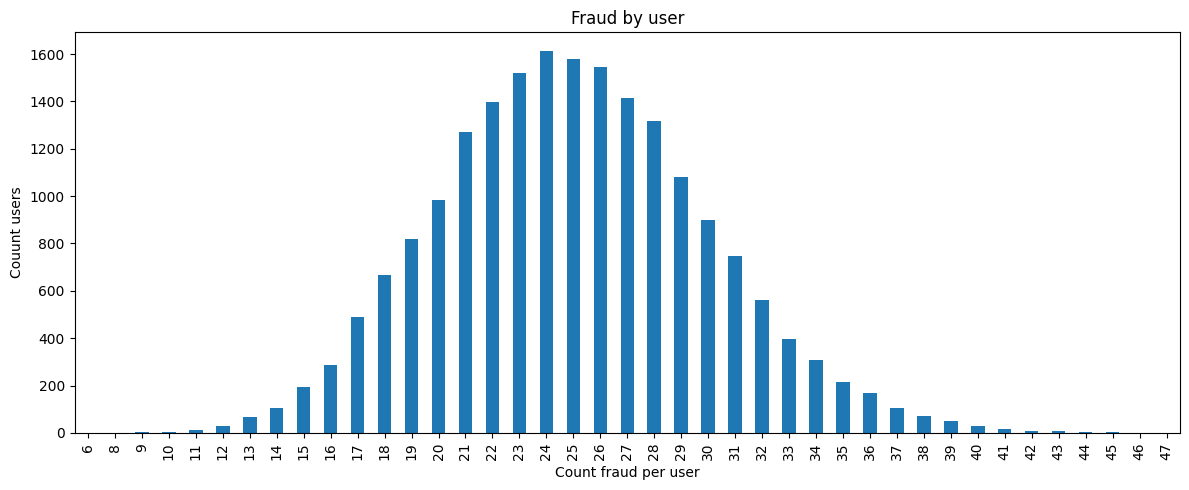

In [50]:
transactions_user =df.groupby('user_id')['is_fraud'].count()

fig, ax = plt.subplots(figsize=(12,5))

transactions_user.value_counts().sort_index().plot(ax=ax, kind="bar")

ax.set_xlabel("Count fraud per user")
ax.set_ylabel("Couunt users")
ax.set_title("Fraud by user")


fig.tight_layout()
plt.show()

In [52]:
# fig, ax = plt.subplots(figsize=(12, 5))

# sns.histplot(data=df_ts, x="hour", hue="is_fraud", bins=24, ax=ax, multiple="stack")

# ax.set_xlabel("Hour")
# ax.set_ylabel("Count")
# ax.set_title("Fraud Frequency by Hour of Day")


# fig.tight_layout()
# plt.show()

user_id
U00001    1
U00002    1
U00003    1
U00004    1
U00005    1
         ..
U19996    1
U19997    1
U19998    1
U19999    1
U20000    0
Name: is_fraud, Length: 20000, dtype: int64

In [56]:
user_stats =(
    df.groupby('user_id')
    .agg(transactions=('is_fraud', 'count'), frauds=('is_fraud', 'sum'))
)

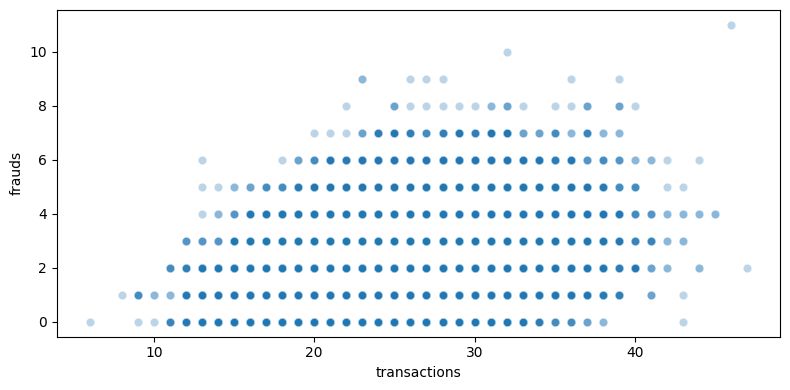

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(
    data=user_stats,
    ax=ax,
    x='transactions',
    y='frauds',
    alpha=0.3)


fig.tight_layout()
plt.show()

In [58]:
corr = user_stats.corr()

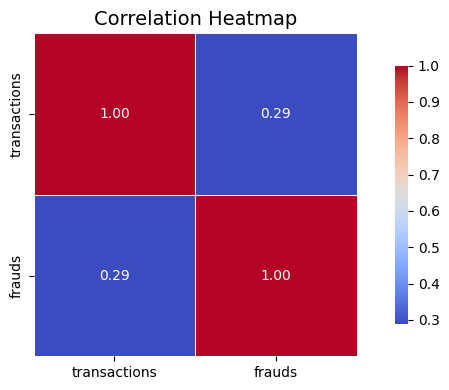

In [60]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,           # poprawka: powinno być 'annot' zamiast 'annotation'
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8},
    cmap="coolwarm",
)

ax.set_title("Correlation Heatmap", fontsize=14)
plt.tight_layout()       # poprawka: tight_layout, nie tight_lauout
plt.show()

### Merchant vs is_fraud

In [61]:
frauds_per_merchant =df.groupby('merchant_id')['is_fraud'].sum()

In [63]:
merchants_stats = (
    df.groupby('merchant_id')
    .agg(transactions=('is_fraud','count'), frauds=('is_fraud', 'sum'))
)

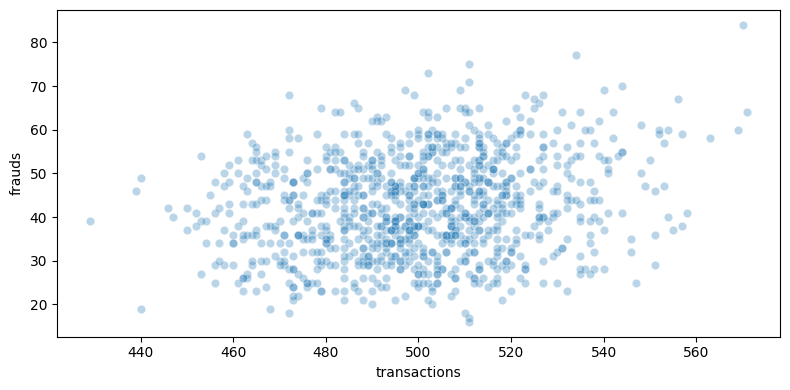

In [65]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(
    data=merchants_stats,
    ax=ax,
    x='transactions',
    y='frauds',
    alpha=0.3)


fig.tight_layout()
plt.show()

In [82]:
fraud_by_merchant = (
    df.groupby('merchant_id')
    .agg(frauds=('is_fraud', 'sum'))
    .sort_values("frauds", ascending=False)
)

top_merchants = fraud_by_merchant.head(1)
print(top_merchants)

             frauds
merchant_id        
M0167            84


In [83]:
df.loc[df["merchant_id"].isin(top_merchants.index)]

,transaction_id,timestamp,user_id,merchant_id,amount,channel,currency,device,location,payment_method,...,country_user,signup_date,risk_score,category,country_merchant,trust_score,number_of_alerts_last_6_months,avg_transaction_amount,account_age_months,has_fraud_history
154,TX000154,2022-01-16 21:22:00,U01157,M0167,218.82,online,EUR,Web,"{'lat': 67.173166, 'long': 32.067447}",debit_card,...,Belgium,2021-05-17,0.417407,clothing,Austria,0.121984,0,77.46,78,1
1359,TX001359,2022-04-09 07:06:00,U16075,M0167,25.06,mobile,EUR,iOS,"{'lat': 68.06013, 'long': -4.49175}",credit_card,...,Czech Republic,2024-04-30,0.275460,clothing,Austria,0.121984,0,77.46,78,1
1597,TX001597,2023-11-09 17:52:00,U14985,M0167,1.61,online,EUR,Web,"{'lat': 57.376999, 'long': 12.967244}",mobile_payment,...,Finland,2024-10-01,0.306114,clothing,Austria,0.121984,0,77.46,78,1
1623,TX001623,2023-11-08 09:27:00,U09748,M0167,70.88,online,EUR,Android,"{'lat': 40.887693, 'long': 30.813473}",bank_transfer,...,Austria,2023-11-25,0.718623,clothing,Austria,0.121984,0,77.46,78,1
2349,TX002349,2022-02-22 06:19:00,U11293,M0167,10.39,online,EUR,Web,"{'lat': 52.18455, 'long': 29.82342}",mobile_payment,...,Netherlands,2021-07-01,0.401525,clothing,Austria,0.121984,0,77.46,78,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495521,TX495521,2023-04-09 17:09:00,U06498,M0167,24.53,online,EUR,Web,"{'lat': 52.263812, 'long': 32.602421}",bank_transfer,...,France,2023-05-20,0.409616,clothing,Austria,0.121984,0,77.46,78,1
495620,TX495620,2022-02-20 12:00:00,U15511,M0167,123.65,mobile,EUR,iOS,"{'lat': 54.094953, 'long': 38.323477}",debit_card,...,Austria,2021-05-21,0.827028,clothing,Austria,0.121984,0,77.46,78,1
496664,TX496664,2023-12-14 09:10:00,U08663,M0167,23.53,in-store,EUR,Android,"{'lat': 35.354135, 'long': 23.242417}",mobile_payment,...,Spain,2023-09-18,0.230708,clothing,Austria,0.121984,0,77.46,78,1
499416,TX499416,2023-08-22 19:03:00,U11839,M0167,15.08,online,EUR,Web,"{'lat': 39.508264, 'long': 22.168626}",bank_transfer,...,Spain,2023-03-25,0.512608,clothing,Austria,0.121984,0,77.46,78,1


### Category vs is_fraud

In [90]:
category_stats = (
    df.groupby('category')
    .agg(transactions=('is_fraud','count'), frauds=('is_fraud', 'sum'))
    .sort_values("frauds", ascending=False)
)

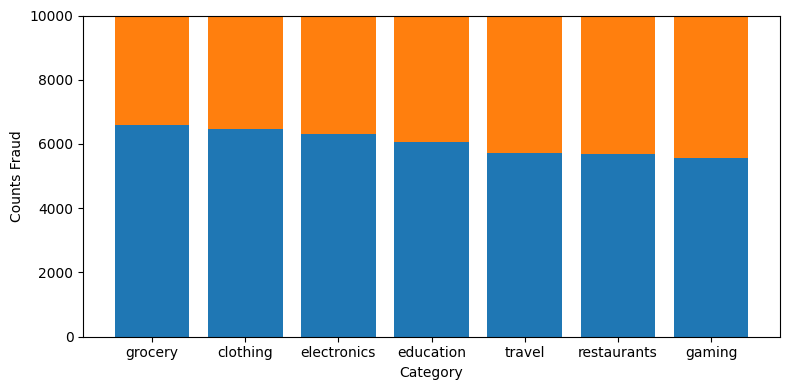

In [127]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(category_stats.index, category_stats['frauds'], label="Frauds")
ax.bar(category_stats.index, category_stats['transactions'] - category_stats["frauds"],bottom=category_stats["frauds"], label="Transactions")


ax.set_xlabel("Category")
ax.set_ylabel("Counts Fraud")

# ax.set_ylim(0, 10000)
fig.tight_layout()
plt.show()

In [99]:
df["category"].value_counts()

category
grocery        78246
electronics    76554
clothing       75988
education      70362
travel         68127
restaurants    67157
gaming         63566
Name: count, dtype: int64

,transactions,frauds
category,,
grocery,78246,6582
clothing,75988,6454
electronics,76554,6318
education,70362,6076
travel,68127,5735
restaurants,67157,5683
gaming,63566,5563


### Corr Matrix

In [147]:
df_numeric = df.select_dtypes(include=['number'])

In [148]:
df_numeric.columns

Index(['amount', 'is_international', 'session_length_seconds',
       'is_first_time_merchant', 'is_fraud', 'age',
       'sum_of_monthly_installments', 'sum_of_monthly_expenses', 'risk_score',
       'trust_score', 'number_of_alerts_last_6_months',
       'avg_transaction_amount', 'account_age_months', 'has_fraud_history'],
      dtype='object')

In [150]:
corr =df_numeric.corr()

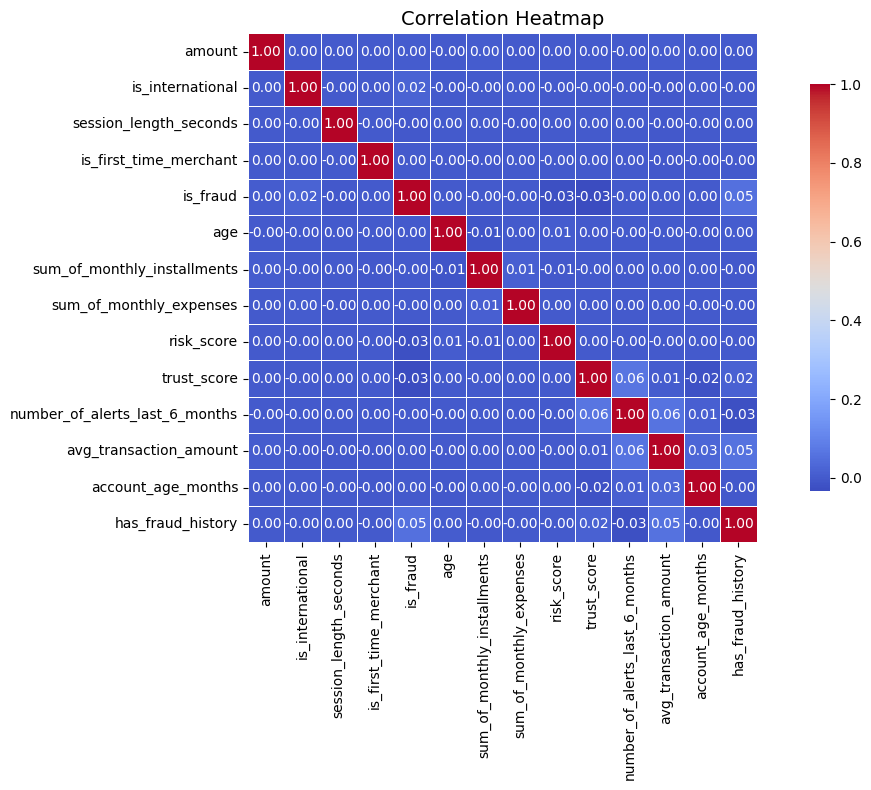

In [151]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,           # poprawka: powinno być 'annot' zamiast 'annotation'
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8},
    cmap="coolwarm",
)

ax.set_title("Correlation Heatmap", fontsize=14)
plt.tight_layout()       # poprawka: tight_layout, nie tight_lauout
plt.show()

### Categorical data

In [157]:
fraud_by_user_country = (df.groupby('country_user')
                        .agg(frauds=('is_fraud','sum'),transactions=('is_fraud','count')) )


In [161]:
fraud_by_user_country.sort_values('frauds',ascending=False)

,frauds,transactions
country_user,,
Finland,3119,35842
Portugal,3108,36872
Austria,3090,35616
Spain,3088,36612
Denmark,3044,36920
Italy,3039,35292
Ireland,3027,35972
Netherlands,3006,35517
Germany,3003,34925


In [163]:
df_international=df.loc[df['country_user'] == df['country_merchant']]

In [169]:
df_international.shape

(35669, 30)

In [168]:
df_international.groupby('is_international')['is_international'].count()

is_international
0    35669
Name: is_international, dtype: int64

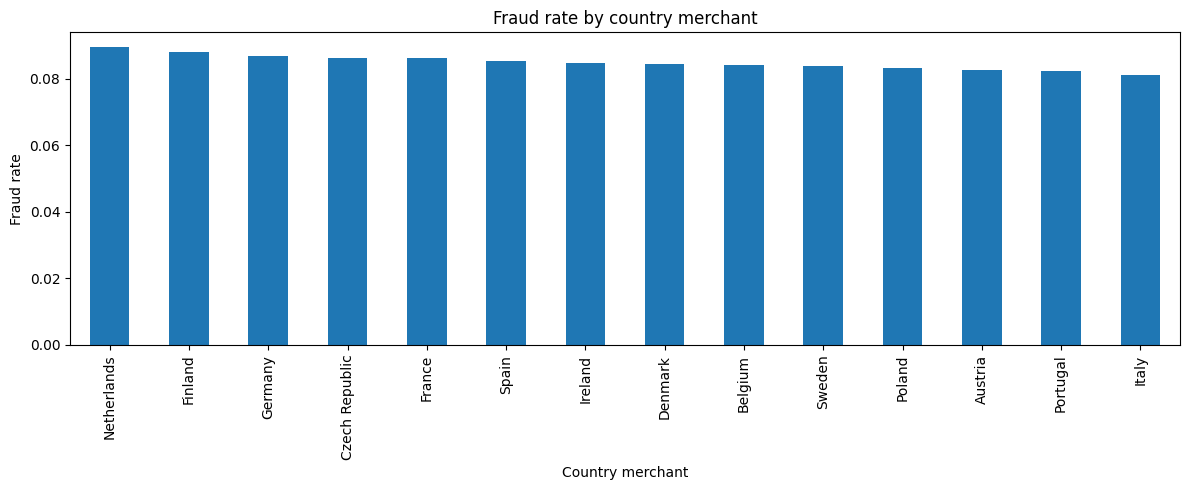

In [170]:
fraud_rate_by_country_merchant = (
    df.groupby('country_merchant')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
fraud_rate_by_country_merchant.plot(kind='bar', ax=ax)

ax.set_title('Fraud rate by country merchant')
ax.set_xlabel('Country merchant')
ax.set_ylabel('Fraud rate')

plt.tight_layout()
plt.show()

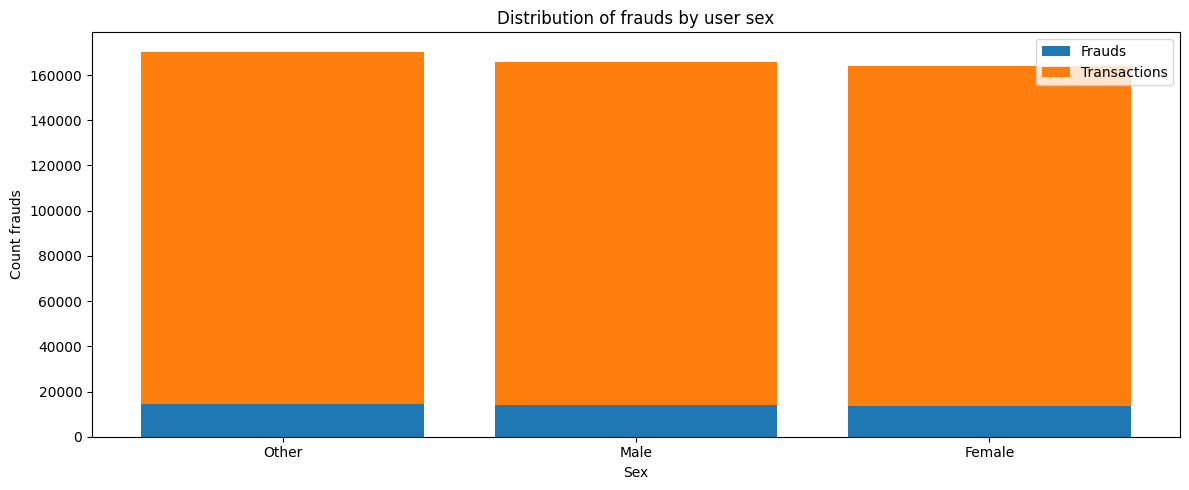

In [174]:
stats = (
    df.groupby('sex')
    .agg(frauds=('is_fraud', 'sum'), transactions=('is_fraud', 'count'))
    .sort_values('frauds', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(stats.index, stats['frauds'], label="Frauds")
ax.bar(
    stats.index,
    stats['transactions'] - stats['frauds'],
    bottom=stats['frauds'],
    label="Transactions"
)
ax.legend()
ax.set_title("Distribution of frauds by user sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Count frauds")

fig.tight_layout()
# plt.savefig()  # zakomentowane w oryginale
plt.show()

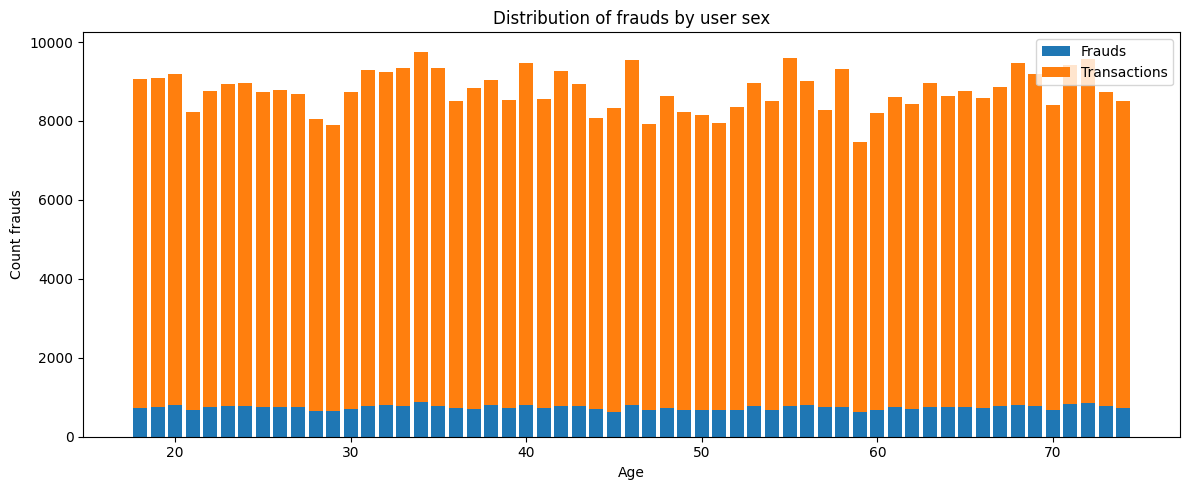

In [173]:
stats = (
    df.groupby('age')
    .agg(frauds=('is_fraud', 'sum'), transactions=('is_fraud', 'count'))
    .sort_values('frauds', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(stats.index, stats['frauds'], label="Frauds")
ax.bar(
    stats.index,
    stats['transactions'] - stats['frauds'],
    bottom=stats['frauds'],
    label="Transactions"
)
ax.legend()
ax.set_title("Distribution of frauds by user sex")
ax.set_xlabel("Age")
ax.set_ylabel("Count frauds")

fig.tight_layout()
# plt.savefig()  # zakomentowane w oryginale
plt.show()

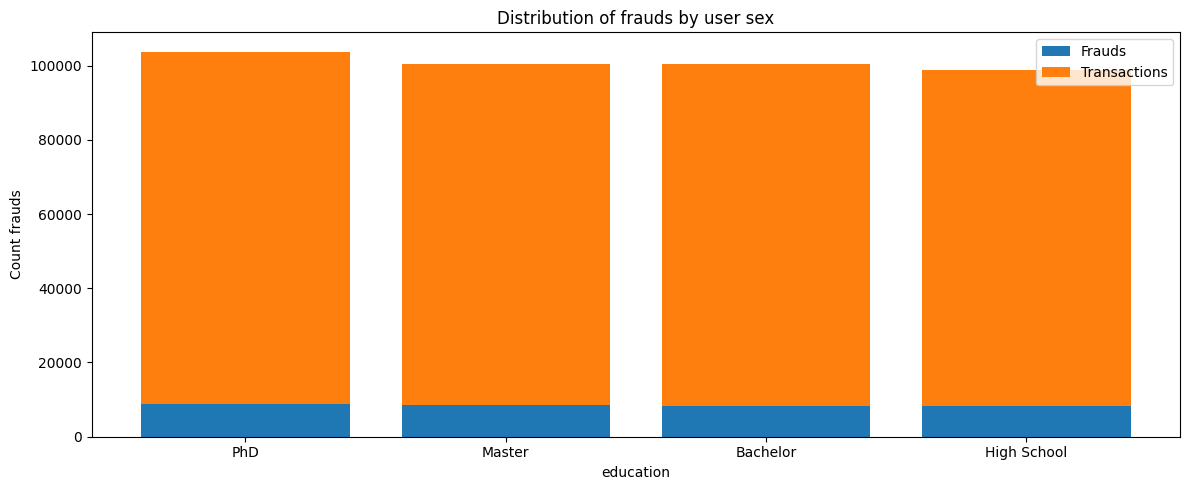

In [175]:
stats = (
    df.groupby('education')
    .agg(frauds=('is_fraud', 'sum'), transactions=('is_fraud', 'count'))
    .sort_values('frauds', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(stats.index, stats['frauds'], label="Frauds")
ax.bar(
    stats.index,
    stats['transactions'] - stats['frauds'],
    bottom=stats['frauds'],
    label="Transactions"
)
ax.legend()
ax.set_title("Distribution of frauds by user sex")
ax.set_xlabel("education")
ax.set_ylabel("Count frauds")

fig.tight_layout()
# plt.savefig()  # zakomentowane w oryginale
plt.show()

In [179]:
df_date =df.loc[df['timestamp'] < df['signup_date']]

In [180]:
df_date.value_counts('is_fraud')

is_fraud
0    206674
1     19236
Name: count, dtype: int64